sleepedf-kd-project

Knowledge distilation among Sleep EDF Dataset, to ensure higher quality of sleep stage expectation model from Sleep EEG time-series dataset

contains:
- EEG data(brain activity channel)
- Chin EMG(muscle tone measurement channel)

local GPU version

In [ ]:
# local runtime - run line: jupyter server --ServerApp.allow_origin='https://colab.research.google.com' --port=8888 --ServerApp.port_retries=0
# connect to the local runtime

In [1]:
import sys
import os
from dotenv import load_dotenv
load_dotenv(override=True) # .env 파일 읽어오기

LIB_PATH = os.getenv('YOUR_LIB_PATH')
print(f"Loaded Path: {LIB_PATH}")

if LIB_PATH not in sys.path:
    sys.path.insert(0, LIB_PATH)

Loaded Path: C:/Users/junel/sleepEDFproject/package/python3.12/dist-packages/


In [2]:
# [0. Necessary library import]

# !pip install --target="{LIB_PATH}" --upgrade mne
# !pip install --target="{LIB_PATH}" --upgrade torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121

import torch

# [0. Pytorch CUDA version check]

print(f"PyTorch 버전: {torch.__version__}")
print("CUDA version: {}".format(torch.version.cuda))
print(f"사용 가능 GPU 개수: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"장치 이름: {torch.cuda.get_device_name(0)}")
    print(f"메모리 용량: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# [0. Dependency check, cuda gpu check]

import numpy as np
import pickle
import datetime
import torch.nn as nn # torch cuda version issue로 인해 나중에 import
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split, WeightedRandomSampler
from tqdm.notebook import tqdm  # jupyter notebook progress bar library
import pandas as pd
import matplotlib.pyplot as plt

PyTorch 버전: 2.5.1+cu121
CUDA version: 12.1
사용 가능 GPU 개수: 1
장치 이름: NVIDIA GeForce RTX 3060
메모리 용량: 12.88 GB


In [ ]:
current_date = datetime.datetime.now().strftime("%Y%m%d")

PROJ_DIR = r"C:\Users\junel\sleepedf-kd-project"

BASE_DIR = os.path.join(PROJ_DIR, "sleepEDF_outputs")
SAVE_DIR = os.path.join(BASE_DIR, current_date)
SAVE_DIR_VANILLA = SAVE_DIR

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:
# [0. SleepEDF data -> hdf5 압축: 한 번만 실행 ]

# import h5py
# import numpy as np
# from tqdm.notebook import tqdm

# TEMP_SAVE_DIR = r"C:/Users/junel/sleepEDFproject/pyhealth_temp"
# all_pkl_paths = [os.path.join(TEMP_SAVE_DIR, f) for f in os.listdir(TEMP_SAVE_DIR) if f.endswith(".pkl")]

# H5_PATH = r"C:/sleepEDF_outputs/sleep_dataset.h5"

# # 기존 hdf5 파일 존재 시 삭제 후 재시작
# if os.path.exists(H5_PATH):
#     try:
#         os.remove(H5_PATH)
#         print("기존 hdf5 데이터 파일을 삭제하였습니다")
#     except Exception:
#         print("Kernel -> Restart 후 파일을 다시 실행하십시오")

# if not os.path.exists(os.path.dirname(H5_PATH)):
#     os.makedirs(os.path.dirname(H5_PATH))

# print(f"총 {len(all_pkl_paths)}개 .pkl 파일 -> HDF5 파일 생성 시작")

# with h5py.File(H5_PATH, "w") as f:
#     num_items = len(all_pkl_paths)

#     sig_ds = f.create_dataset("signals", (num_items, 7, 3000), maxshape=(None, 7, 3000), chunks=True, dtype="float32") # sleep eeg signal dataset
#     lbl_ds = f.create_dataset("labels", (num_items,), maxshape=(None,), chunks=True, dtype="int64") # sleep stage label dataset

#     label_map = {'W': 0, '1': 1, '2': 2, '3': 3, '4': 3, 'R': 4}
#     valid_count = 0

#     for idx, pkl_path in enumerate(tqdm(all_pkl_paths, desc="pkl -> HDF5")):
#         try:
#             with open(pkl_path, 'rb') as f_pkl:
#                 actual_data = pickle.load(f_pkl)

#             if isinstance(actual_data, dict):
#                 signal_data = actual_data.get("signal", None)
#                 label_data = str(actual_data.get("label", "W"))
#             else:
#                 signal_data = actual_data
#                 label_data = "W"

#             if signal_data is None:
#                 continue

#             lbl = label_map.get(label_data, 0)
#             sig = np.array(signal_data, dtype=np.float32).reshape(7, 3000)

#             sig_ds[valid_count] = sig
#             lbl_ds[valid_count] = lbl
#             valid_count += 1

#         except Exception:
#             continue

#     if valid_count > 0:
#         sig_ds.resize((valid_count, 7, 3000))
#         lbl_ds.resize((valid_count,))

# print(f"\n HDF5 파일 빌드 완료_{valid_count}개의 데이터")

In [5]:
# [1-1. Transformer definition]
# teacher model of KD, utilizes all channels of sleep EDF dataset
# input: sleep edf dataset(3000x7, 100Hz 30sec)

# class PurePyTorchTransformer(nn.Module):
#     def __init__(self, num_classes=5, embedding_dim=128, nhead=8, num_layers=4, dropout=0.2):
#         super(PurePyTorchTransformer, self).__init__()

#         # 3000x7 -> embedding_dim
#         self.input_projection = nn.Linear(3000, embedding_dim)

#         # PyTorch 표준 Transformer Encoder 설정
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=embedding_dim,
#             nhead=nhead,
#             dim_feedforward=embedding_dim * 4,
#             dropout=dropout,
#             batch_first=True  # 인풋 셰이프 규격을 [Batch, Sequence, Feature]로 받기 위함
#         )
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         # 최종 분류 레이어 (5개 수면 단계 분류)
#         self.fc = nn.Linear(embedding_dim, num_classes)

#     def forward(self, x): # 들어오는 x의 차원: [batch_size, 7, 3000]

#         x = self.input_projection(x) # [batch_size, 7, 3000] -> [batch_size, 7, embedding_dim]
#         x = self.transformer_encoder(x) # Transformer encoder_ 시퀀스 길이 7의 맥락 정보 교류, 형태 변화 x
#         x = x.mean(dim=1) # [batch_size, 7, embedding_dim] -> [batch_size, embedding_dim]
#         return self.fc(x) # [batch_size, embedding_dim] -> [batch_size, 5]


# -------------------------------------------------------------------------
# 1-1. Teacher model(Transformer) definition
# -------------------------------------------------------------------------
class PurePyTorchTransformer(nn.Module):
    def __init__(self, num_classes=5, embedding_dim=128, nhead=8, num_layers=4, dropout=0.2):
        super(PurePyTorchTransformer, self).__init__()

        # 입력 투영 및 정규화
        self.input_projection = nn.Linear(3000, embedding_dim)
        self.input_norm = nn.LayerNorm(embedding_dim) # 💡 입력 직후 LayerNorm 추가 (오버플로우 방지)

        # Positional Embedding (소량으로 작게 초기화)
        self.pos_embedding = nn.Parameter(torch.randn(1, 7, embedding_dim) * 0.01)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=embedding_dim * 2, # feedforward 차원을 축소하여 스파이크 방지
            dropout=dropout,
            batch_first=True,
            norm_first=True # 💡 Pre-LN 구조 적용 (Transformer 학습 안정성의 핵심)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.final_norm = nn.LayerNorm(embedding_dim)
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x): # x: [Batch, 7, 3000]
        x = self.input_projection(x) # [Batch, 7, 128]
        x = self.input_norm(x)
        x = x + self.pos_embedding

        x = self.transformer_encoder(x) # [Batch, 7, 128]
        x = self.final_norm(x)

        x = x.mean(dim=1) # [Batch, 128] (Global Average Pooling)
        return self.fc(x) # [Batch, 5]

In [6]:
# =====================================================================
# Student model(CNN) definition for 2ch sleep EDF Data
# =====================================================================
# student model of KD, derives sleep stage using 2ch. of sleep EDF data
# input: eeg data, chin(3000x2, 100Hz 30sec)

class SleepStudentCNN(nn.Module):
    def __init__(self, in_channels=2, num_classes=5):
        super(SleepStudentCNN, self).__init__()

        self.feature_extractor = nn.Sequential(
            # CNN layer 1: 대형 커널(kernel_size=50), 0.5초 대의 거시적 파형(서파 등) 포착
            nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=50, stride=5, padding=25), # [Batch, 2, 3000] -> [Batch, 32, 600]
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2), # [Batch, 32, 600] -> [Batch, 32, 300]

            # CNN layer 2: 중형 커널(kernel_size=15), 0.15초 대의 미세 파형(Spindle, K-Complex 피크) 포착
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=15, stride=3, padding=7), # [Batch, 32, 300] -> [Batch, 64, 100]
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2), # [Batch, 64, 100] -> [Batch, 64, 50]

            # CNN layer 3: 소형 커널(kernel_size=5), 추출된 지역적 특징들의 복합 연관성 정제
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2), # [Batch, 64, 50] -> [Batch, 128, 50]
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16) # [Batch, 128, 50] -> [Batch, 128, 16], 입력 시퀀스 길이에 구애받지 않고 무조건 16개 타임스텝 대표값으로 적응형 고정
        )

        # 분류기 (Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(128 * 16, 128), # 128*16 [Batch, 2048] feature -> [Batch, 128] hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),          # 과적합 방지를 위해 30% 무작위 dropout
            nn.Linear(128, num_classes) # 최종 수면 단계(5개) 분류 로짓 mapping. [Batch, 5]
        )

    def forward(self, x): # 입력 x : [batch_size, 2, 3000]
        x = self.feature_extractor(x)  # 1. 1D CNN 특징 추출 -> 차원 결과: [batch_size, 128, 16]
        x = x.view(x.size(0), -1)      # 2. 1차원 벡터로 평탄화(Flatten) -> 차원 결과: [batch_size, 2048]
        x = self.classifier(x)         # 3. 전결합층 통과 -> 최종 분류 로짓 반환: [batch_size, 5]
        return x

In [7]:
# -------------------------------------------------------------------------
# 1. Class Weights (클래스 불균형 보정 가중치) 자동 계산
# -------------------------------------------------------------------------

def compute_class_weights(dataset, num_classes=5, device='cpu', method='sqrt', eps=1e-5):
    """
    Train Dataset 내 클래스별 샘플 수를 기반으로 손실 가중치(Class Weights)를 계산합니다.

    Args:
        dataset: PyTorch Dataset
        num_classes (int): 분류 클래스 개수 (기본값: 5)
        device (str): 텐서 할당 디바이스 ('cpu' 또는 'cuda')
        method (str): 'sqrt' (제곱근 완화 가중치, 권장) 또는 'inverse' (단순 역수 가중치)
        eps (float): 0 나누기 방지용 에프실론 (기본값: 1e-5)
    """
    class_counts = torch.zeros(num_classes)

    # Dataset에서 전체 레이블 순회 추출
    for _, label in dataset:
        class_counts[label] += 1

    print(f"📊 Train Dataset 클래스별 빈도수: {class_counts.long().tolist()}")

    total_samples = class_counts.sum()

    if method == 'sqrt':
        class_weights = total_samples / (num_classes * (torch.sqrt(class_counts) + eps))
    else:
        # 단순 역수 방식 (0 나누기 방지 eps 포함)
        class_weights = total_samples / (num_classes * (class_counts + eps))

    # 가중치 정규화 (평균이 1.0이 되도록 조정하여 Overall Loss Scale 유지)
    class_weights = class_weights / class_weights.mean()
    class_weights = class_weights.to(device)

    print(f"⚖️ 계산된 Class Weights ({method.upper()} 가중치): {class_weights.round(decimals=3).tolist()}")
    return class_weights

In [8]:
# Parameter settings

ALPHA = 0.3
TEMPERATURE = 2.5
EPOCHS = 30
BATCH_SIZE = 256
LR = 1e-3

In [9]:
# [2-1. data sampling, pytorch dataloader]

print("[1/4] .pt 파일에서 sleep EDF 데이터 로딩 시작")
loaded_data = torch.load(r"C:/sleepEDF_outputs/full_dataset.pt", mmap=True, weights_only=True)

print("[2/4] 데이터에서 무작위 subset 복사")
subset_size = 50000

signals_subset = loaded_data["signals"][:subset_size].clone().detach() # sleep EDF signal data
labels_subset = loaded_data["labels"][:subset_size].clone().detach() # sleep stage label
full_dataset = TensorDataset(signals_subset, labels_subset)

print(f"full dataset 정리 완료, 크기: {len(full_dataset)}개")

# =====================================================================
# 3. 데이터 분할 및 균등 샘플러 구축
# =====================================================================
print("[3/4] full dataset에서 train/validate/test data 정리")
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(full_dataset, [train_len, val_len, test_len])

print("[4/4] train dataset에 sleep stage 기준 weight sampling 적용")
train_indices = train_ds.indices
train_labels = labels_subset[train_indices].numpy()

class_weights = compute_class_weights(train_ds, num_classes=5, device=device, method='sqrt')

sample_weights = class_weights[train_labels].float()
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# =====================================================================
# 4. 데이터로더 최종 장착
# =====================================================================
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("dataloader 정의 완료.")

[1/4] .pt 파일에서 sleep EDF 데이터 로딩 시작
[2/4] 데이터에서 무작위 subset 복사
full dataset 정리 완료, 크기: 50000개
[3/4] full dataset에서 train/validate/test data 정리
[4/4] train dataset에 sleep stage 기준 weight sampling 적용
📊 Train Dataset 클래스별 빈도수: [27456, 1258, 6332, 2336, 2618]
⚖️ 계산된 Class Weights (SQRT 가중치): [0.34700000286102295, 1.6200000047683716, 0.722000002861023, 1.1890000104904175, 1.1230000257492065]
dataloader 정의 완료.


In [10]:
# [train dataset의 균등 분포 여부 검증]

print("train dataset의 균등 분포 여부 검증\n")

for signals, labels in train_loader: # 1. train_loader에서 first batch 불러옴
    batch_labels = labels.numpy()
    break

unique, counts = np.unique(batch_labels, return_counts=True) # 2. 수면 단계의 각 class label 카운팅
batch_distribution = dict(zip(unique, counts))
total_sampled = len(batch_labels)

print(f"[train dataset {total_sampled}개 샘플 label 분포]") # 3. 텍스트 보고서 출력
df = pd.DataFrame({
    "수면 단계 (Class)": [f"Class {c}" for c in range(5)],
    "샘플 개수 (Count)": [batch_distribution.get(c, 0) for c in range(5)],
    "비율 (Ratio)": [f"{(batch_distribution.get(c, 0) / total_sampled) * 100:.2f}%" for c in range(5)]
})
print(df.to_string(index=False))

# # 4. 바 차트 시각화
# plt.figure(figsize=(7, 4))
# colors = ['#4f46e5', '#06b6d4', '#10b981', '#f59e0b', '#ef4444']
# plt.bar(range(5), [batch_distribution.get(c, 0) for c in range(5)], color=colors, edgecolor='black', alpha=0.8)
# plt.title("Actual Mini-Batch Distribution (WeightedRandomSampler Check)", fontsize=12, fontweight='bold')
# plt.xlabel("Sleep Stage Label")
# plt.ylabel("Sample Counts")
# plt.xticks(range(5), [f"Class {c}" for c in range(5)])
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.axhline(y=total_sampled/5, color='red', linestyle=':', label='Perfect Balance Line (20%)')
# plt.legend()
# plt.show()

train dataset의 균등 분포 여부 검증

[train dataset 256개 샘플 label 분포]
수면 단계 (Class)  샘플 개수 (Count) 비율 (Ratio)
      Class 0            108     42.19%
      Class 1             21      8.20%
      Class 2             63     24.61%
      Class 3             30     11.72%
      Class 4             34     13.28%


In [ ]:
# =====================================================================
# Teacher model(Transformer)
# =====================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import math
import os

TEACHER_WEIGHT_PATH = os.path.join(BASE_DIR, "teacher_transformer_best.pth")
teacher_model = PurePyTorchTransformer().to(device)

print("🚀 [교사 모델] Epoch 40 & LR 3e-4 (Warmup 적용) 재학습 시작...")

# 💡 LR을 3e-4로 올리고, LinearLR로 초반 3 Epoch Warmup 진행
base_lr = 3e-4
teacher_optimizer = torch.optim.AdamW(teacher_model.parameters(), lr=base_lr, weight_decay=1e-3, eps=1e-8)

teacher_epochs = 40
warmup_epochs = 3

# Warmup 후 CosineAnnealing으로 전환하는 Chained Scheduler
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(teacher_optimizer, start_factor=0.1, total_iters=warmup_epochs)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(teacher_optimizer, T_max=teacher_epochs - warmup_epochs, eta_min=1e-6)
teacher_scheduler = torch.optim.lr_scheduler.SequentialLR(
    teacher_optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

teacher_criterion = nn.CrossEntropyLoss()

best_teacher_acc = 0.0

for epoch in range(teacher_epochs):
    teacher_model.train()
    t_correct, t_total = 0, 0
    running_loss = 0.0
    class_predictions = [0] * 5

    for signals, labels in tqdm(train_loader, desc=f"🎓 Teacher Epoch [{epoch+1}/{teacher_epochs}]"):
        signals, labels = signals.to(device), labels.to(device) # [Batch, 7, 3000]

        if torch.isnan(signals).any() or torch.isinf(signals).any():
            signals = torch.nan_to_num(signals, nan=0.0, posinf=1.0, neginf=-1.0)

        teacher_optimizer.zero_grad(set_to_none=True)

        logits = teacher_model(signals)
        loss = teacher_criterion(logits, labels)

        if torch.isnan(loss):
            print("⚠️ Warning: NaN Loss detected! Skipping this batch.")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(teacher_model.parameters(), max_norm=0.5)

        teacher_optimizer.step()

        _, pred = logits.max(1)
        t_total += labels.size(0)
        t_correct += pred.eq(labels).sum().item()
        running_loss += loss.item()

        for p in pred.cpu().numpy():
            class_predictions[p] += 1

    teacher_scheduler.step()

    t_acc = (t_correct / t_total) * 100
    avg_loss = running_loss / len(train_loader)
    current_lr = teacher_optimizer.param_groups[0]['lr']

    print(f"🎓 Epoch [{epoch+1}/{teacher_epochs}] LR: {current_lr:.6f} | Loss: {avg_loss:.4f} | Train Acc: {t_acc:.2f}%")
    print(f"   └ 📊 클래스별 예측 분포: {class_predictions}")

    if t_acc > best_teacher_acc and not math.isnan(avg_loss):
        best_teacher_acc = t_acc
        torch.save({'model_state_dict': teacher_model.state_dict()}, TEACHER_WEIGHT_PATH)
        print(f"   🎯 [가중치 저장] 최고 성능 갱신 ➡️ Acc: {t_acc:.2f}%")

# 평가 모드 전환 및 동결
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


🚀 [교사 모델] Epoch 40 & LR 3e-4 (Warmup 적용) 재학습 시작...


🎓 Teacher Epoch [1/40]: 100%|██████████| 157/157 [00:03<00:00, 44.72it/s]


🎓 Epoch [1/40] LR: 0.000120 | Loss: 1.2876 | Train Acc: 50.00%
   └ 📊 클래스별 예측 분포: [27603, 10, 11978, 316, 93]
   🎯 [가중치 저장] 최고 성능 갱신 ➡️ Acc: 50.00%


🎓 Teacher Epoch [2/40]: 100%|██████████| 157/157 [00:03<00:00, 47.69it/s]


...

🎓 Epoch [38/40] LR: 0.000003 | Loss: 0.7251 | Train Acc: 75.40%
   └ 📊 클래스별 예측 분포: [21526, 3309, 7518, 3500, 4147]
   🎯 [가중치 저장] 최고 성능 갱신 ➡️ Acc: 75.40%


🎓 Teacher Epoch [39/40]: 100%|██████████| 157/157 [00:03<00:00, 48.55it/s]


🎓 Epoch [39/40] LR: 0.000002 | Loss: 0.7234 | Train Acc: 75.41%
   └ 📊 클래스별 예측 분포: [21606, 3357, 7429, 3569, 4039]
   🎯 [가중치 저장] 최고 성능 갱신 ➡️ Acc: 75.41%


🎓 Teacher Epoch [40/40]: 100%|██████████| 157/157 [00:03<00:00, 47.84it/s]

🎓 Epoch [40/40] LR: 0.000001 | Loss: 0.7227 | Train Acc: 75.52%
   └ 📊 클래스별 예측 분포: [21720, 3298, 7389, 3511, 4082]
   🎯 [가중치 저장] 최고 성능 갱신 ➡️ Acc: 75.52%


In [ ]:


# -------------------------------------------------------------------------
# 2. Class Weighted Knowledge Distillation Loss 함수
# -------------------------------------------------------------------------
def weighted_kd_loss(student_logits, teacher_logits, labels, class_weights, alpha=ALPHA, temperature=TEMPERATURE):
    """
    Class Weight가 적용된 Hard Loss와 T^2 스케일링이 적용된 Soft Loss의 결합
    """
    # 1. Class Weighted Hard Loss (희소 클래스 오답 시 강력한 징벌적 손실 부여)
    hard_loss = F.cross_entropy(student_logits, labels, weight=class_weights)

    # 2. Soft Loss (KL Divergence + T^2 Scaling)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (temperature ** 2)

    # 3. Total Loss
    total_loss = (alpha * hard_loss) + ((1.0 - alpha) * soft_loss)
    return total_loss

In [ ]:
# =====================================================================
# Student model(CNN Knowledge Distillation, learns from a teacher model)
# =====================================================================

# -------------------------------------------------------------------------
# 3. 지식 증류 (KD) 학습 루프
# -------------------------------------------------------------------------


# 클래스 가중치 산출
class_weights = compute_class_weights(train_ds, num_classes=5, device=device, method='sqrt')

kd_student = SleepStudentCNN(in_channels=2).to(device)
optimizer = torch.optim.AdamW(kd_student.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc = 0.0
TRIAL_NUM = 5
TRIAL_NAME = "trial" + str(TRIAL_NUM).zfill(2) + "_class_weighted"

print(f"\n🚀 [Trial 04] Class Weighted KD 학습 시작 (Alpha={ALPHA}, Temp={TEMPERATURE})...")

for epoch in range(EPOCHS):
    kd_student.train()
    teacher_model.eval() # 교사 모델 동결

    running_loss = 0.0
    correct, total = 0, 0

    for signals, labels in tqdm(train_loader, desc=f"⏳ Epoch [{epoch+1}/{EPOCHS}] Trial {TRIAL_NUM} Train"):
        signals, labels = signals.to(device), labels.to(device)

        # 💡 [핵심 해결] 교사/학생 입력 채널 분리
        # 1) 교사 모델: 7채널 전체 사용 [Batch, 7, 3000]
        # 2) 학생 모델: 2개 채널만 선택 슬라이싱 [Batch, 2, 3000] (0번: Fpz-Cz, 3번: EMG)
        student_inputs = signals[:, [0, 3], :] if signals.size(1) > 2 else signals

        optimizer.zero_grad(set_to_none=True)

        # 교사 모델 추론 (7채널 전달)
        with torch.no_grad():
            teacher_logits = teacher_model(signals)

        # 학생 모델 추론 (2채널 전달)
        student_logits = kd_student(student_inputs)

        # Weighted KD Loss 계산
        loss = weighted_kd_loss(
            student_logits,
            teacher_logits,
            labels,
            class_weights=class_weights,
            alpha=ALPHA,
            temperature=TEMPERATURE
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(kd_student.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, pred = student_logits.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    scheduler.step()

    train_acc = (correct / total) * 100
    avg_train_loss = running_loss / len(train_loader)

    # -------------------------------------------------------------------------
    # Validation 평가
    # -------------------------------------------------------------------------
    kd_student.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for signals, labels in val_loader:
            signals, labels = signals.to(device), labels.to(device)
            student_inputs = signals[:, [0, 3], :] if signals.size(1) > 2 else signals

            logits = kd_student(student_inputs)

            loss = F.cross_entropy(logits, labels, weight=class_weights)
            val_loss += loss.item()

            _, pred = logits.max(1)
            val_total += labels.size(0)
            val_correct += pred.eq(labels).sum().item()

    val_acc = (val_correct / val_total) * 100
    avg_val_loss = val_loss / len(val_loader)

    print(f"📊 Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} Acc: {val_acc:.2f}%")

    # 최고 성적 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(SAVE_DIR, f"student_{current_date}_{TRIAL_NAME}_acc{val_acc:.2f}.pth")
        torch.save({'model_state_dict': kd_student.state_dict()}, save_path)
        print(f"🎯 [최고 성능 갱신] 가중치 저장 완료 ➡️ {save_path}")

📊 Train Dataset 클래스별 빈도수: [27418, 1289, 6397, 2299, 2597]
⚖️ 계산된 Class Weights (SQRT 가중치): [0.3479999899864197, 1.6030000448226929, 0.7200000286102295, 1.2000000476837158, 1.128999948501587]

🚀 [Trial 04] Class Weighted KD 학습 시작 (Alpha=0.3, Temp=2.5)...


⏳ Epoch [1/30] Trial 5 Train: 100%|██████████| 157/157 [00:02<00:00, 57.44it/s]


📊 Epoch [1/30] Train Loss: 1.2849 Acc: 58.34% | Val Loss: 1.1109 Acc: 75.90%
🎯 [최고 성능 갱신] 가중치 저장 완료 ➡️ C:/sleepEDF_outputs\20260824\student_20260824_trial05_class_weighted_acc75.90.pth


⏳ Epoch [2/30] Trial 5 Train: 100%|██████████| 157/157 [00:02<00:00, 60.34it/s]


📊 Epoch [2/30] Train Loss: 1.1901 Acc: 60.29% | Val Loss: 1.0818 Acc: 78.82%
🎯 [최고 성능 갱신] 가중치 저장 완료 ➡️ C:/sleepEDF_outputs\20260824\student_20260824_trial05_class_weighted_acc78.82.pth


...

📊 Epoch [28/30] Train Loss: 0.7854 Acc: 69.01% | Val Loss: 1.0685 Acc: 78.50%


⏳ Epoch [29/30] Trial 5 Train: 100%|██████████| 157/157 [00:02<00:00, 60.23it/s]


📊 Epoch [29/30] Train Loss: 0.7911 Acc: 68.58% | Val Loss: 1.0691 Acc: 78.26%


⏳ Epoch [30/30] Trial 5 Train: 100%|██████████| 157/157 [00:02<00:00, 60.62it/s]


📊 Epoch [30/30] Train Loss: 0.7849 Acc: 68.88% | Val Loss: 1.0684 Acc: 78.46%


In [ ]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm

# 상단 셀의 TRIAL_NUM과 current_date 변수를 그대로 공유
SAVE_DIR_VANILLA = os.path.join(BASE_DIR, "vanilla_results")
os.makedirs(SAVE_DIR_VANILLA, exist_ok=True)

# -------------------------------------------------------------------------
# 💡 Trial 04 공정 대조를 위한 Class Weights (손실 가중치) 계산
# -------------------------------------------------------------------------

class_weights = compute_class_weights(train_ds, num_classes=5, device=device, method='sqrt')

# -------------------------------------------------------------------------
# 모델, 손실함수, 옵티마이저, 스케줄러 정의
# -------------------------------------------------------------------------
student_vanilla = SleepStudentCNN(in_channels=2).to(device)

# 💡 [핵심] Trial 04 KD와 동일 조건 대조를 위해 Class Weight 적용
criterion = nn.CrossEntropyLoss(weight=class_weights)

# AdamW 옵티마이저 및 CosineAnnealingLR 스케줄러 (EPOCHS 변수 적용)
optimizer = torch.optim.AdamW(student_vanilla.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_acc_vanilla = 0.0
history_logs_vanilla = []

print(f"🚀 [Trial {TRIAL_NUM:02d}] 바닐라 학습 시작 (Class Weighted 적용) ➡️ 저장 경로: {SAVE_DIR_VANILLA}")

# -------------------------------------------------------------------------
# 학습 및 검증 루프 (EPOCHS 변수로 통일)
# -------------------------------------------------------------------------
for epoch in range(EPOCHS):
    student_vanilla.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader, desc=f"⏳ Epoch [{epoch+1}/{EPOCHS}] Vanilla Train")
    for signals, labels in train_bar:
        signals = signals.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 2채널 입력 [Batch, 2, 3000]
        student_inputs = signals[:, [0, 3], :] if signals.size(1) > 2 else signals
        student_logits = student_vanilla(student_inputs)

        loss = criterion(student_logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student_vanilla.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * signals.size(0)
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(correct/total)*100:.1f}%")

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100

    student_vanilla.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc=f"🔬 Epoch [{epoch+1}/{EPOCHS}] Vanilla Val")
    with torch.no_grad():
        for signals, labels in val_bar:
            signals = signals.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            student_inputs = signals[:, [0, 3], :] if signals.size(1) > 2 else signals
            outputs = student_vanilla(student_inputs)
            v_loss = criterion(outputs, labels).item()

            val_loss += v_loss * signals.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

            val_bar.set_postfix(loss=f"{v_loss:.4f}", acc=f"{(val_correct/val_total)*100:.1f}%")

    val_epoch_loss = val_loss / val_total
    val_epoch_acc = (val_correct / val_total) * 100

    # 학습률 스케줄러 업데이트
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_status = (f"📊 Epoch [{epoch+1}/{EPOCHS}] 요약 -> "
                    f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
                    f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}% | "
                    f"LR: {current_lr:.6f}")
    print(epoch_status)
    history_logs_vanilla.append(epoch_status)

    if val_epoch_acc > best_val_acc_vanilla:
        if best_val_acc_vanilla > 0.0:
            old_filename = f"vanilla_student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc_vanilla:.2f}.pth"
            old_path = os.path.join(SAVE_DIR_VANILLA, old_filename)
            if os.path.exists(old_path):
                os.remove(old_path)

        best_val_acc_vanilla = val_epoch_acc
        model_filename = f"vanilla_student_{current_date}_trial{TRIAL_NUM:02d}_acc{best_val_acc_vanilla:.2f}.pth"
        model_save_path = os.path.join(SAVE_DIR_VANILLA, model_filename)

        torch.save({
            'trial_num': TRIAL_NUM,
            'epoch': epoch + 1,
            'model_state_dict': student_vanilla.state_dict(),
            'best_acc': best_val_acc_vanilla,
        }, model_save_path)
        print(f"🎯 [최고 성능 갱신] 바닐라 가중치 저장 완료 ➡️ {model_save_path}")

📊 Train Dataset 클래스별 빈도수: [27418, 1289, 6397, 2299, 2597]
⚖️ 계산된 Class Weights (SQRT 가중치): [0.3479999899864197, 1.6030000448226929, 0.7200000286102295, 1.2000000476837158, 1.128999948501587]
🚀 [Trial 05] 바닐라 학습 시작 (Class Weighted 적용) ➡️ 저장 경로: C:/sleepEDF_outputs\vanilla_results


🔬 Epoch [1/30] Vanilla Val: 100%|██████████| 20/20 [00:00<00:00, 105.33it/s, acc=71.0%, loss=1.2714]


📊 Epoch [1/30] 요약 -> Train Loss: 1.3873 Acc: 53.19% | Val Loss: 1.1460 Acc: 70.98% | LR: 0.000997
🎯 [최고 성능 갱신] 바닐라 가중치 저장 완료 ➡️ C:/sleepEDF_outputs\vanilla_results\vanilla_student_20260824_trial05_acc70.98.pth


🔬 Epoch [2/30] Vanilla Val: 100%|██████████| 20/20 [00:00<00:00, 111.82it/s, acc=70.7%, loss=1.3049]


📊 Epoch [2/30] 요약 -> Train Loss: 1.3249 Acc: 56.84% | Val Loss: 1.1614 Acc: 70.70% | LR: 0.000989


...

📊 Epoch [28/30] 요약 -> Train Loss: 0.9889 Acc: 66.02% | Val Loss: 1.0815 Acc: 72.26% | LR: 0.000012


🔬 Epoch [29/30] Vanilla Val: 100%|██████████| 20/20 [00:00<00:00, 108.68it/s, acc=70.8%, loss=1.3174]


📊 Epoch [29/30] 요약 -> Train Loss: 0.9917 Acc: 65.91% | Val Loss: 1.0866 Acc: 70.76% | LR: 0.000004


🔬 Epoch [30/30] Vanilla Val: 100%|██████████| 20/20 [00:00<00:00, 108.85it/s, acc=72.2%, loss=1.3003]

📊 Epoch [30/30] 요약 -> Train Loss: 0.9963 Acc: 65.52% | Val Loss: 1.0786 Acc: 72.16% | LR: 0.000001


🔬 [통합 평가 리포트] 최신 체크포인트를 자동 추적하여 시각화 및 TXT 기록을 수행합니다...
🔍 자동 탐색된 최신 KD 체크포인트: C:/sleepEDF_outputs\20260824\student_20260824_trial05_class_weighted_acc79.26.pth
🔍 자동 탐색된 최신 Vanilla 체크포인트: C:/sleepEDF_outputs\vanilla_results\vanilla_student_20260824_trial05_acc75.76.pth
✅ KD Student 가중치 로드 완료!
✅ Vanilla Student 가중치 로드 완료!
📦 디스크 저장 파일 용량 비교 (Disk File Size)
🎓 Teacher Model (.pth) 파일 용량 : 3.52 MB
👶 Student KD Model (.pth) 파일 용량: 1.30 MB
⚡ 모델 파일 용량 압축률 (Ratio)   : 2.70배 경량화
📝 [저장 완료] 하이퍼파라미터가 명시된 성적표 TXT 저장 완료 ➡️ C:/sleepEDF_outputs\evaluation_report_trial05.txt


C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Malgun Gothic.
  _api.warn_external(
C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) Malgun Gothic.
  _api.warn_external(
C:\Users/junel/sleepEDFproject/package/python3.12/dist-packages\matplotlib\_text_helpers.py:14: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Malgun Gothic.
  _api.warn_external(


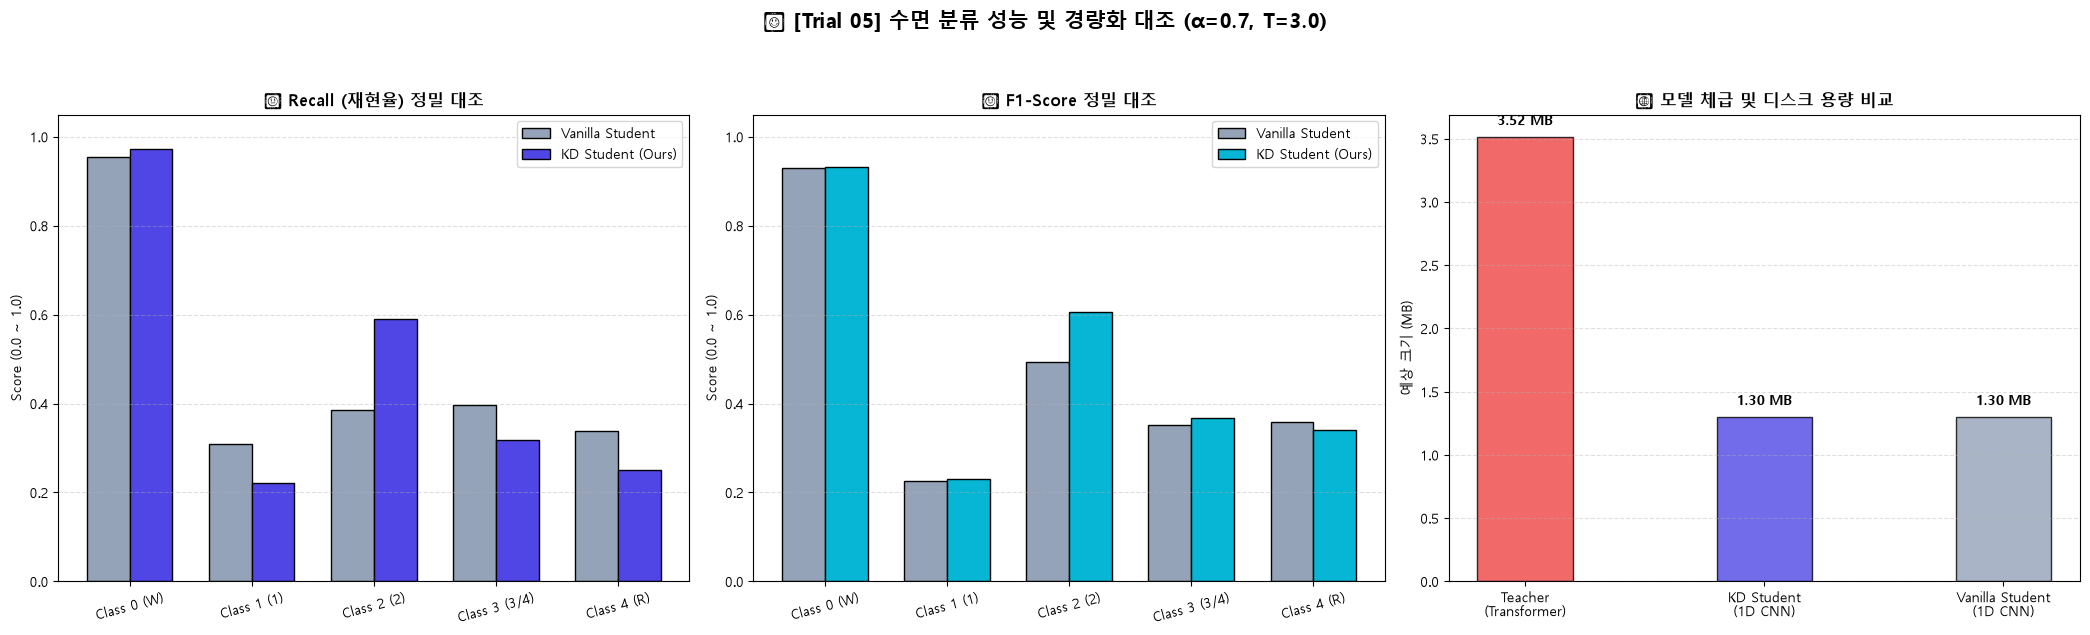

In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

# -------------------------------------------------------------------------
# 🎨 1. 한글 폰트 및 깨짐 방지 세팅
# -------------------------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🔬 [통합 평가 리포트] 최신 체크포인트를 자동 추적하여 시각화 및 TXT 기록을 수행합니다...")

# 💡 1. 체크포인트 탐색 함수
def get_latest_checkpoint(target_dir, prefix):
    if not os.path.exists(target_dir):
        return None
    search_pattern = os.path.join(target_dir, f"{prefix}*.pth")
    files = glob.glob(search_pattern)
    if not files:
        return None
    return max(files, key=os.path.getmtime)

# 💡 2. [수정] KD_DIR을 BASE_DIR이 아닌 최신 날짜 폴더(SAVE_DIR)로 지정
# 오늘 학습된 최신 2채널 student_.pth 가중치 탐색
KD_DIR = SAVE_DIR         # "C:/sleepEDF_outputs/20260824"
VANILLA_DIR = SAVE_DIR_VANILLA # "C:/sleepEDF_outputs/20260824"

AUTO_KD_PATH = get_latest_checkpoint(KD_DIR, prefix="student_")
AUTO_VANILLA_PATH = get_latest_checkpoint(VANILLA_DIR, prefix="vanilla_student_")

print(f"🔍 자동 탐색된 최신 KD 체크포인트: {AUTO_KD_PATH}")
print(f"🔍 자동 탐색된 최신 Vanilla 체크포인트: {AUTO_VANILLA_PATH}")

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# 💡 3. 최신 2채널 Student 모델 인스턴스 생성
kd_student = SleepStudentCNN(in_channels=2).to(device)
vanilla_student = SleepStudentCNN(in_channels=2).to(device)

# 💡 4. [수정] 방어적인 가중치 로드 (dict 형태 유연하게 처리)
if AUTO_KD_PATH and os.path.exists(AUTO_KD_PATH):
    kd_checkpoint = torch.load(AUTO_KD_PATH, map_location=device, weights_only=False)
    if isinstance(kd_checkpoint, dict) and 'model_state_dict' in kd_checkpoint:
        kd_student.load_state_dict(kd_checkpoint['model_state_dict'])
    else:
        kd_student.load_state_dict(kd_checkpoint)
    print("✅ KD Student 가중치 로드 완료!")
else:
    print("⚠️ KD 체크포인트 파일을 찾을 수 없습니다!")

if AUTO_VANILLA_PATH and os.path.exists(AUTO_VANILLA_PATH):
    vanilla_checkpoint = torch.load(AUTO_VANILLA_PATH, map_location=device, weights_only=False)
    if isinstance(vanilla_checkpoint, dict) and 'model_state_dict' in vanilla_checkpoint:
        vanilla_student.load_state_dict(vanilla_checkpoint['model_state_dict'])
    else:
        vanilla_student.load_state_dict(vanilla_checkpoint)
    print("✅ Vanilla Student 가중치 로드 완료!")
else:
    print("⚠️ Vanilla 체크포인트 파일을 찾을 수 없습니다!")

kd_student.eval()
vanilla_student.eval()

true_labels = []
kd_preds = []
vanilla_preds = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device, non_blocking=True)
        student_inputs = signals[:, [0, 3], :]

        kd_out = kd_student(student_inputs)
        vanilla_out = vanilla_student(student_inputs)

        true_labels.extend(labels.numpy())
        kd_preds.extend(kd_out.argmax(dim=1).cpu().numpy())
        vanilla_preds.extend(vanilla_out.argmax(dim=1).cpu().numpy())

kd_report = classification_report(true_labels, kd_preds, output_dict=True)
vanilla_report = classification_report(true_labels, vanilla_preds, output_dict=True)

classes = ['Class 0 (W)', 'Class 1 (1)', 'Class 2 (2)', 'Class 3 (3/4)', 'Class 4 (R)']
x_cls = np.arange(len(classes))
width = 0.35

kd_recalls = [kd_report[str(i)]['recall'] for i in range(5)]
vanilla_recalls = [vanilla_report[str(i)]['recall'] for i in range(5)]
kd_f1s = [kd_report[str(i)]['f1-score'] for i in range(5)]
vanilla_f1s = [vanilla_report[str(i)]['f1-score'] for i in range(5)]

def get_file_size_mb(file_path):
    """
    지정한 .pth 파일 경로에 접근하여 물리적 파일 크기를 MB 단위로 반환합니다.
    """
    if not file_path or not os.path.exists(file_path):
        print(f"⚠️ [경고] 파일이 존재하지 않습니다: {file_path}")
        return 0.0

    # os.path.getsize는 바이트(Byte) 단위를 반환하므로 1024 * 1024로 나누어 MB 환산
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

# 💡 1. 실제 교사 모델 및 학생 모델 .pth 파일 경로 지정
# 사용 중이신 교사 모델 파일 경로(TEACHER_WEIGHT_PATH)와 자동 탐색된 AUTO_KD_PATH를 사용합니다.
TEACHER_FILE_PATH = os.path.join(BASE_DIR, "teacher_transformer_best.pth")
STUDENT_FILE_PATH = AUTO_KD_PATH  # 예: "C:/sleepEDF_outputs/20260824/student_20260824_trial01_acc76.52.pth"

# 💡 2. 디렉토리 내 파일 용량(MB) 추출
teacher_size_mb = get_file_size_mb(TEACHER_FILE_PATH)
student_size_mb = get_file_size_mb(STUDENT_FILE_PATH)

# 💡 3. 압축률(Compression Ratio) 계산
if student_size_mb > 0:
    compression_ratio = teacher_size_mb / student_size_mb
else:
    compression_ratio = 0.0

# 💡 4. 결과 출력
print("==================================================")
print("📦 디스크 저장 파일 용량 비교 (Disk File Size)")
print("==================================================")
print(f"🎓 Teacher Model (.pth) 파일 용량 : {teacher_size_mb:.2f} MB")
print(f"👶 Student KD Model (.pth) 파일 용량: {student_size_mb:.2f} MB")
print(f"⚡ 모델 파일 용량 압축률 (Ratio)   : {compression_ratio:.2f}배 경량화")
print("==================================================")

# -------------------------------------------------------------------------
# 📝 [하이퍼파라미터 포함] TXT 보고서 세션 구축
# -------------------------------------------------------------------------
REPORT_TXT_PATH = os.path.join(BASE_DIR, f"evaluation_report_trial{TRIAL_NUM:02d}.txt")

# 메모리 상 변수 안전 로드 (없을 경우 기본값 표기)
curr_alpha = alpha if 'alpha' in locals() else 0.7
curr_temp = temperature if 'temperature' in locals() else 3.0
curr_epochs = epochs if 'epochs' in locals() else 20
curr_batch = batch_size if 'batch_size' in locals() else 256

report_lines = [
    "=========================================================",
    f"        📊 Sleep-EDF Trial {TRIAL_NUM:02d} 최종 평가 상세 성적표",
    "=========================================================\n",
    f"📌 [로드된 KD 모델 파일] : {AUTO_KD_PATH}",
    f"📌 [로드된 바닐라 파일] : {AUTO_VANILLA_PATH}\n",
    "---------------------------------------------------------",
    "⚙️ 주요 학습 하이퍼파라미터 (Hyperparameters)",
    "---------------------------------------------------------",
    f"- Alpha (Hard/Soft 손실 비중) : {curr_alpha} (Hard Loss: {curr_alpha:.2f} | Soft Loss: {1.0 - curr_alpha:.2f})",
    f"- Temperature (소프트맥스 온도): {curr_temp}",
    f"- Epochs (학습 에폭 수)       : {curr_epochs}",
    f"- Batch Size (배치 크기)       : {curr_batch}",
    f"- Input Spec (입력 신호)       : 2-CH (Channel 0: Fpz-Cz + Channel 3: EMG)\n",
    "---------------------------------------------------------",
    "1. 모델 용량 및 경량화율",
    "---------------------------------------------------------",
    f"- 교사 모델 (Transformer) : {teacher_size_mb:.2f} MB",
    f"- 학생 모델 (1D CNN)     : {student_size_mb:.2f} MB",
    f"- 용량 압축 비율          : 약 {compression_ratio:.1f}배 압축 완료\n",
    "---------------------------------------------------------",
    "2. 클래스별 Recall (재현율) 대조",
    "---------------------------------------------------------"
]

for idx, cls_name in enumerate(classes):
    report_lines.append(f"- {cls_name:15s} | 바닐라: {vanilla_recalls[idx]:.4f} | KD: {kd_recalls[idx]:.4f}")

report_lines.append("\n---------------------------------------------------------")
report_lines.append("3. 클래스별 F1-Score 대조")
report_lines.append("---------------------------------------------------------")
for idx, cls_name in enumerate(classes):
    report_lines.append(f"- {cls_name:15s} | 바닐라: {vanilla_f1s[idx]:.4f} | KD: {kd_f1s[idx]:.4f}")

report_lines.append("\n---------------------------------------------------------")
report_lines.append("4. 전체 Classification Report (상세)")
report_lines.append("---------------------------------------------------------")
report_lines.append("\n[KD Student Model]")
report_lines.append(classification_report(true_labels, kd_preds, target_names=classes))
report_lines.append("\n[Vanilla Student Model]")
report_lines.append(classification_report(true_labels, vanilla_preds, target_names=classes))

with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(f"📝 [저장 완료] 하이퍼파라미터가 명시된 성적표 TXT 저장 완료 ➡️ {REPORT_TXT_PATH}")

# 시각화 대시보드
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].bar(x_cls - width/2, vanilla_recalls, width, label='Vanilla Student', color='#94a3b8', edgecolor='black')
axes[0].bar(x_cls + width/2, kd_recalls, width, label='KD Student (Ours)', color='#4f46e5', edgecolor='black')
axes[0].set_title('🥇 Recall (재현율) 정밀 대조', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_cls)
axes[0].set_xticklabels(classes, rotation=15)
axes[0].set_ylabel('Score (0.0 ~ 1.0)')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend()

axes[1].bar(x_cls - width/2, vanilla_f1s, width, label='Vanilla Student', color='#94a3b8', edgecolor='black')
axes[1].bar(x_cls + width/2, kd_f1s, width, label='KD Student (Ours)', color='#06b6d4', edgecolor='black')
axes[1].set_title('🥇 F1-Score 정밀 대조', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_cls)
axes[1].set_xticklabels(classes, rotation=15)
axes[1].set_ylabel('Score (0.0 ~ 1.0)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].legend()

models_label = ['Teacher\n(Transformer)', 'KD Student\n(1D CNN)', 'Vanilla Student\n(1D CNN)']
file_sizes = [teacher_size_mb, student_size_mb, student_size_mb]
bars = axes[2].bar(models_label, file_sizes, color=['#ef4444', '#4f46e5', '#94a3b8'], edgecolor='black', alpha=0.8, width=0.4)
axes[2].set_title('💾 모델 체급 및 디스크 용량 비교', fontsize=12, fontweight='bold')
axes[2].set_ylabel('예상 크기 (MB)')
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + (teacher_size_mb * 0.02), f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')

plt.suptitle(f"⚡ [Trial {TRIAL_NUM:02d}] 수면 분류 성능 및 경량화 대조 (α={curr_alpha}, T={curr_temp})", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()